Starting implicit solver with variable properties but no latent heat...
Diagnostics:
  T range      : [-11.926392, 1.000000]
  phi range    : [0.075933, 1.000000]
  C_eff range  : [1.704976, 2.632000]
  lambda range : [0.119750, 0.175478]
  dx = 0.050000, dt = 0.073005
  Progress: 10.0%   elapsed: 1.1s
  Progress: 20.0%   elapsed: 2.2s
  Progress: 30.0%   elapsed: 3.2s
  Progress: 40.0%   elapsed: 4.2s
  Progress: 50.0%   elapsed: 5.2s
  Progress: 60.0%   elapsed: 6.3s
  Progress: 70.0%   elapsed: 7.3s
  Progress: 80.0%   elapsed: 8.3s
  Progress: 90.0%   elapsed: 9.4s
Implicit solution completed in 10.4s
Diagnostics:
  T range      : [-11.926392, 1.033622]
  phi range    : [0.075933, 1.000000]
  C_eff range  : [1.704976, 2.632000]
  lambda range : [0.119750, 0.175478]
  dx = 0.050000, dt = 0.073005
Last-year results saved to variable_properties_no_latent_last_year.npz
All-years T min = -12.079999989780223
All-years T max = 20.13999975659201
Surface final T = -11.92639217305949
Bottom 

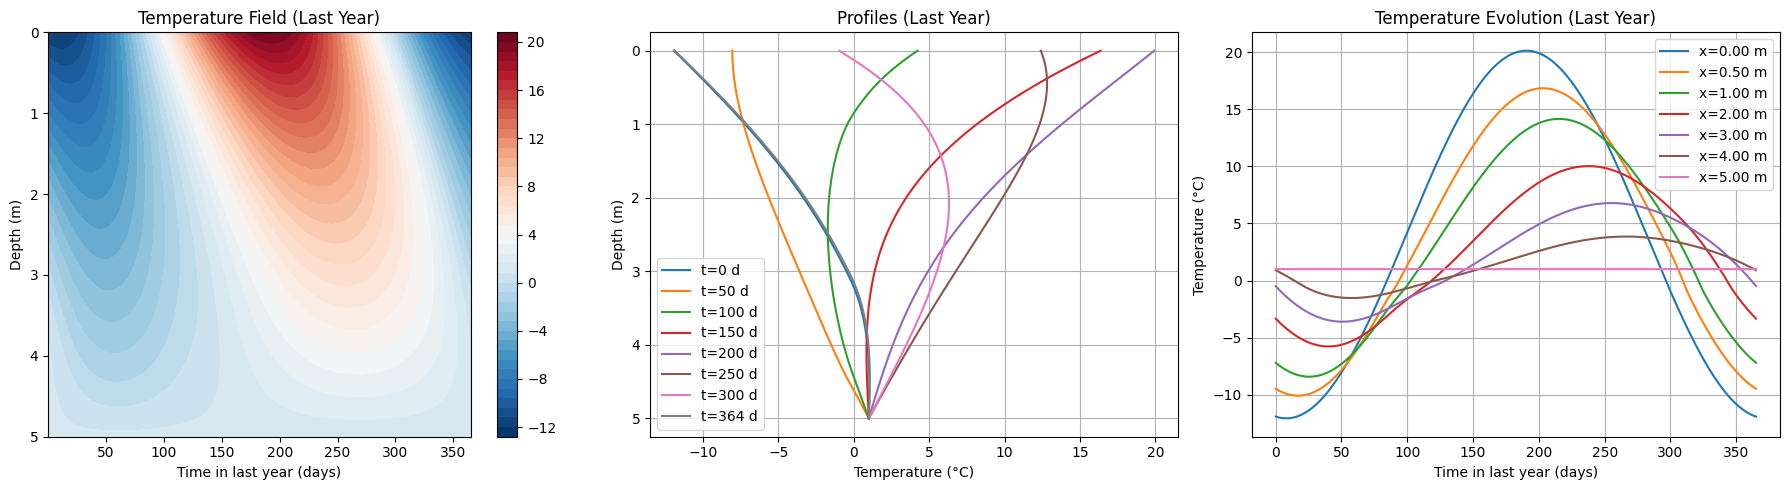

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time


class HeatConduction1DVariableProperties:
    """
    1D heat conduction model with temperature-dependent properties:
        C_eff(T), lambda_eff(T)
    but without latent heat term.

    This model is used to test whether the problem comes from:
    - variable material properties
    or
    - latent heat / phase change treatment
    """

    def __init__(self, params):
        # ---------------- Physical parameters ----------------
        self.C_i = params['C_i']
        self.C_l = params['C_l']
        self.C_f = params['C_f']
        self.lambda_i = params['lambda_i']
        self.lambda_l = params['lambda_l']
        self.lambda_f = params['lambda_f']
        self.eta = params['eta']
        self.b = params['b']
        self.T_nabla = params['T_nabla']

        # ---------------- Smoothing parameters ----------------
        self.k_phi = params.get('k_phi', 1.5)
        self.eps_phi = params.get('eps_phi', 1e-6)

        # ---------------- Grid parameters ----------------
        self.Nx = None
        self.Nt = None
        self.Lx = None
        self.T_total = None
        self.dx = None
        self.dt = None

        self.x = None
        self.t = None
        self.T_field = None

    # ============================================================
    # Boundary / initial conditions
    # ============================================================
    def boundary_temperature(self, t):
        return 4.03 + 16.11 * np.sin(2.0 * np.pi * t / 365.0 - 1.709)

    def initial_temperature_profile(self, x):
        T_surface = self.boundary_temperature(0.0)
        T_bottom = 1.0
        return T_surface + (T_bottom - T_surface) / 5.0 * x

    # ============================================================
    # Stable sigmoid
    # ============================================================
    def stable_sigmoid(self, z):
        z = np.asarray(z, dtype=float)
        z = np.clip(z, -60.0, 60.0)
        return 1.0 / (1.0 + np.exp(-z))

    # ============================================================
    # Constitutive relations
    # ============================================================
    def pore_water_content(self, T):
        """
        Smoothed pore liquid water fraction phi(T), physically constrained to [0, 1].
        """
        T = np.asarray(T, dtype=float)
        T_abs = np.clip(np.abs(T), self.eps_phi, None)

        phi_frozen = (abs(self.T_nabla) ** self.b) * (T_abs ** (-self.b))
        phi_frozen = np.minimum(phi_frozen, 1.0)

        z = self.k_phi * (T - self.T_nabla)
        step = self.stable_sigmoid(z)

        phi = step * 1.0 + (1.0 - step) * phi_frozen
        return np.clip(phi, 0.0, 1.0)

    def effective_heat_capacity(self, T):
        phi = self.pore_water_content(T)
        return (
            (1.0 - self.eta) * self.C_f
            + self.eta * (phi * self.C_l + (1.0 - phi) * self.C_i)
        )

    def effective_conductivity(self, T):
        phi = self.pore_water_content(T)
        return (
            (1.0 - self.eta) * self.lambda_f
            + self.eta * (phi * self.lambda_l + (1.0 - phi) * self.lambda_i)
        )

    @staticmethod
    def harmonic_mean(a, b, eps=1e-12):
        return 2.0 * a * b / (a + b + eps)

    # ============================================================
    # Initialization
    # ============================================================
    def initialize(self, Nx=101, Nt=15000, Lx=5.0, T_total=365.0 * 3):
        self.Nx = Nx
        self.Nt = Nt
        self.Lx = Lx
        self.T_total = T_total

        self.dx = Lx / (Nx - 1)
        self.dt = T_total / (Nt - 1)

        self.x = np.linspace(0.0, Lx, Nx)
        self.t = np.linspace(0.0, T_total, Nt)

        self.T_field = np.zeros((Nx, Nt), dtype=float)
        self.T_field[:, 0] = self.initial_temperature_profile(self.x)

    # ============================================================
    # Diagnostics
    # ============================================================
    def print_diagnostics(self, T):
        phi = self.pore_water_content(T)
        Ceff = self.effective_heat_capacity(T)
        lam = self.effective_conductivity(T)

        print("Diagnostics:")
        print(f"  T range      : [{np.min(T):.6f}, {np.max(T):.6f}]")
        print(f"  phi range    : [{np.min(phi):.6f}, {np.max(phi):.6f}]")
        print(f"  C_eff range  : [{np.min(Ceff):.6f}, {np.max(Ceff):.6f}]")
        print(f"  lambda range : [{np.min(lam):.6f}, {np.max(lam):.6f}]")
        print(f"  dx = {self.dx:.6f}, dt = {self.dt:.6f}")

    # ============================================================
    # Implicit solver
    # ============================================================
    def solve_implicit(self, verbose=True):
        """
        Implicit solver for:
            C_eff(T) * dT/dt = d/dx( lambda_eff(T) * dT/dx )

        Material properties are evaluated at old time step (semi-implicit).
        """
        if self.T_field is None:
            raise RuntimeError("Please call initialize() first.")

        start = time.time()
        T = self.T_field[:, 0].copy()

        if verbose:
            print("Starting implicit solver with variable properties but no latent heat...")
            self.print_diagnostics(T)

        for n in range(1, self.Nt):
            t_n = self.t[n]

            C_eff = self.effective_heat_capacity(T)
            lambda_eff = self.effective_conductivity(T)

            A = np.zeros((self.Nx, self.Nx), dtype=float)
            b = np.zeros(self.Nx, dtype=float)

            # Boundary conditions
            A[0, 0] = 1.0
            b[0] = self.boundary_temperature(t_n)

            A[-1, -1] = 1.0
            b[-1] = 1.0

            # Interior nodes
            for i in range(1, self.Nx - 1):
                lam_p = self.harmonic_mean(lambda_eff[i], lambda_eff[i + 1])
                lam_m = self.harmonic_mean(lambda_eff[i], lambda_eff[i - 1])

                alpha = self.dt / (C_eff[i] * self.dx**2)

                A[i, i - 1] = -0.5 * alpha * lam_m
                A[i, i]     =  1.0 + 0.5 * alpha * (lam_p + lam_m)
                A[i, i + 1] = -0.5 * alpha * lam_p

                conduction = 0.5 * alpha * (
                    lam_p * (T[i + 1] - T[i]) - lam_m * (T[i] - T[i - 1])
                )

                b[i] = T[i] + conduction

            T_new = np.linalg.solve(A, b)

            if np.any(np.isnan(T_new)) or np.any(np.isinf(T_new)):
                raise RuntimeError(f"NaN/Inf detected at time step {n}")

            self.T_field[:, n] = T_new
            T = T_new.copy()

            if verbose and n % max(1, self.Nt // 10) == 0:
                print(f"  Progress: {100.0 * n / self.Nt:.1f}%   elapsed: {time.time() - start:.1f}s")

        if verbose:
            print(f"Implicit solution completed in {time.time() - start:.1f}s")
            self.print_diagnostics(T)

        return self.T_field

    # ============================================================
    # Extract last year
    # ============================================================
    def get_last_year_data(self):
        if self.T_field is None:
            raise RuntimeError("No results available.")

        t_start = self.T_total - 365.0
        mask = self.t >= t_start

        t_last = self.t[mask] - t_start
        T_last = self.T_field[:, mask]

        return t_last, T_last

    # ============================================================
    # Save
    # ============================================================
    def save_last_year_results(self, filename='variable_properties_no_latent_last_year.npz'):
        t_last, T_last = self.get_last_year_data()

        np.savez(
            filename,
            x=self.x,
            t=t_last,
            T_field=T_last,
            params={
                'C_i': self.C_i,
                'C_l': self.C_l,
                'C_f': self.C_f,
                'lambda_i': self.lambda_i,
                'lambda_l': self.lambda_l,
                'lambda_f': self.lambda_f,
                'eta': self.eta,
                'b': self.b,
                'T_nabla': self.T_nabla,
                'k_phi': self.k_phi,
                'eps_phi': self.eps_phi
            }
        )
        print(f"Last-year results saved to {filename}")

    # ============================================================
    # Plot last year
    # ============================================================
    def plot_last_year_results(self):
        t_last, T_last = self.get_last_year_data()

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        im = axes[0].contourf(t_last, self.x, T_last, levels=40, cmap='RdBu_r')
        axes[0].invert_yaxis()
        axes[0].set_xlabel('Time in last year (days)')
        axes[0].set_ylabel('Depth (m)')
        axes[0].set_title('Temperature Field (Last Year)')
        plt.colorbar(im, ax=axes[0])

        times_to_plot = [0, 50, 100, 150, 200, 250, 300, 364]
        for tt in times_to_plot:
            idx = np.argmin(np.abs(t_last - tt))
            axes[1].plot(T_last[:, idx], self.x, label=f't={t_last[idx]:.0f} d')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Temperature (°C)')
        axes[1].set_ylabel('Depth (m)')
        axes[1].set_title('Profiles (Last Year)')
        axes[1].legend()
        axes[1].grid(True)

        depths_to_plot = [0, 0.5, 1, 2, 3, 4, 5]
        for dd in depths_to_plot:
            idx = np.argmin(np.abs(self.x - dd))
            axes[2].plot(t_last, T_last[idx, :], label=f'x={self.x[idx]:.2f} m')
        axes[2].set_xlabel('Time in last year (days)')
        axes[2].set_ylabel('Temperature (°C)')
        axes[2].set_title('Temperature Evolution (Last Year)')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    params = {
        'C_i': 1.672,
        'C_l': 4.18,
        'C_f': 1.6,
        'lambda_i': 2.210e-6 * 8.64e4,
        'lambda_l': 0.465e-6 * 8.64e4,
        'lambda_f': 2e-6 * 8.64e4,
        'eta': 0.4,
        'b': 0.7,
        'T_nabla': -0.3,
        'k_phi': 1.5,
        'eps_phi': 1e-6
    }

    model = HeatConduction1DVariableProperties(params)

    # 3-year spin-up
    model.initialize(Nx=101, Nt=15000, Lx=5.0, T_total=365.0 * 3)

    T_field = model.solve_implicit(verbose=True)

    model.save_last_year_results("variable_properties_no_latent_last_year.npz")

    print("All-years T min =", np.min(T_field))
    print("All-years T max =", np.max(T_field))
    print("Surface final T =", T_field[0, -1])
    print("Bottom final T =", T_field[-1, -1])

    model.plot_last_year_results()

Step 1: Solve original FDM
Starting implicit solver with variable properties but no latent heat...
  Progress: 10.0%   elapsed: 1.1s
  Progress: 20.0%   elapsed: 2.1s
  Progress: 30.0%   elapsed: 3.0s
  Progress: 40.0%   elapsed: 4.0s
  Progress: 50.0%   elapsed: 5.0s
  Progress: 60.0%   elapsed: 6.0s
  Progress: 70.0%   elapsed: 6.9s
  Progress: 80.0%   elapsed: 8.0s
  Progress: 90.0%   elapsed: 8.9s
Implicit solution completed in 9.9s
FDM last-year shape: (101, 5000)
FDM min/max: -12.079998816645903 20.13999975659201
Step 2: Build training data from FDM
Training data size: 31875
Step 3: Train PINN
Using device: cuda
Epoch     0 | total=7.856361e+03 | pde=1.598387e-07 | bc=1.479709e+02 | ic=4.469245e+01 | data=4.003094e+01
Epoch   200 | total=2.456931e+01 | pde=5.059688e-02 | bc=1.431070e-01 | ic=2.734860e-01 | data=1.618685e-01
Epoch   400 | total=2.020083e+01 | pde=3.159520e-02 | bc=4.620236e-02 | ic=2.353030e-01 | data=1.453913e-01
Epoch   600 | total=2.308379e+01 | pde=2.665147e-0

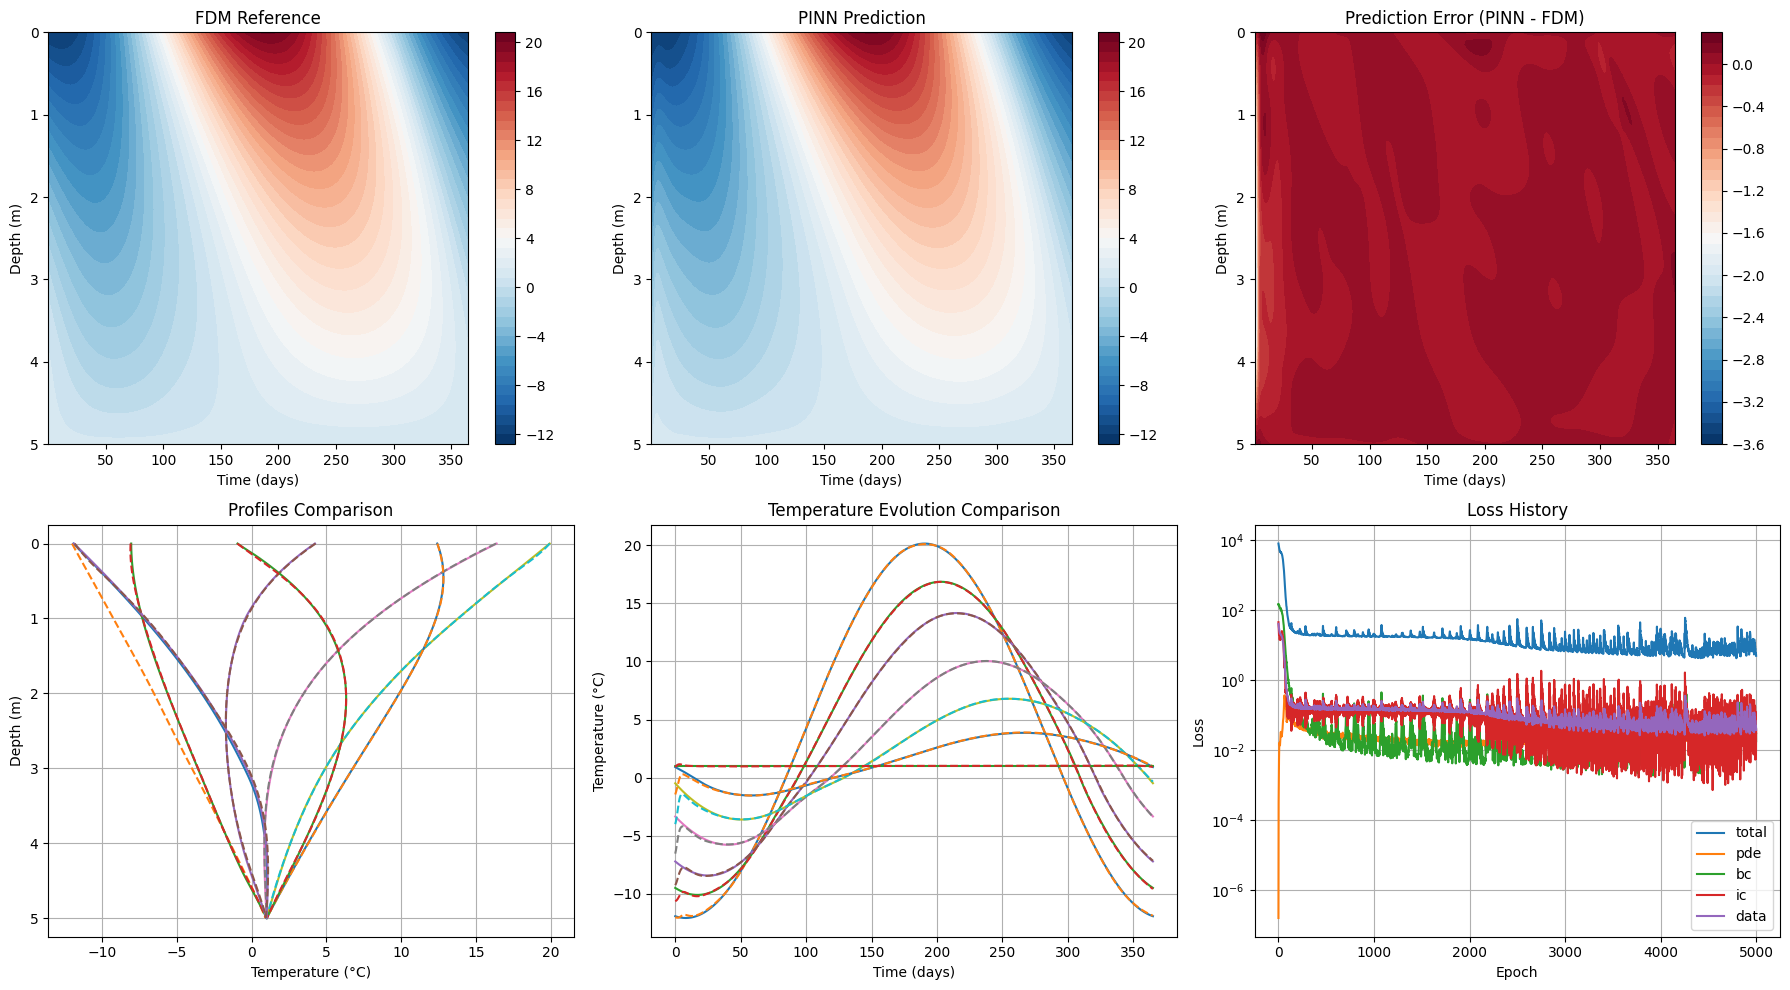

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time

import torch
import torch.nn as nn
import torch.optim as optim


# ============================================================
# Original FDM model from your code
# ============================================================
class HeatConduction1DVariableProperties:
    """
    1D heat conduction model with temperature-dependent properties:
        C_eff(T), lambda_eff(T)
    but without latent heat term.
    """

    def __init__(self, params):
        self.C_i = params['C_i']
        self.C_l = params['C_l']
        self.C_f = params['C_f']
        self.lambda_i = params['lambda_i']
        self.lambda_l = params['lambda_l']
        self.lambda_f = params['lambda_f']
        self.eta = params['eta']
        self.b = params['b']
        self.T_nabla = params['T_nabla']

        self.k_phi = params.get('k_phi', 1.5)
        self.eps_phi = params.get('eps_phi', 1e-6)

        self.Nx = None
        self.Nt = None
        self.Lx = None
        self.T_total = None
        self.dx = None
        self.dt = None

        self.x = None
        self.t = None
        self.T_field = None

    def boundary_temperature(self, t):
        return 4.03 + 16.11 * np.sin(2.0 * np.pi * t / 365.0 - 1.709)

    def initial_temperature_profile(self, x):
        T_surface = self.boundary_temperature(0.0)
        T_bottom = 1.0
        return T_surface + (T_bottom - T_surface) / 5.0 * x

    def stable_sigmoid(self, z):
        z = np.asarray(z, dtype=float)
        z = np.clip(z, -60.0, 60.0)
        return 1.0 / (1.0 + np.exp(-z))

    def pore_water_content(self, T):
        T = np.asarray(T, dtype=float)
        T_abs = np.clip(np.abs(T), self.eps_phi, None)

        phi_frozen = (abs(self.T_nabla) ** self.b) * (T_abs ** (-self.b))
        phi_frozen = np.minimum(phi_frozen, 1.0)

        z = self.k_phi * (T - self.T_nabla)
        step = self.stable_sigmoid(z)

        phi = step * 1.0 + (1.0 - step) * phi_frozen
        return np.clip(phi, 0.0, 1.0)

    def effective_heat_capacity(self, T):
        phi = self.pore_water_content(T)
        return (
            (1.0 - self.eta) * self.C_f
            + self.eta * (phi * self.C_l + (1.0 - phi) * self.C_i)
        )

    def effective_conductivity(self, T):
        phi = self.pore_water_content(T)
        return (
            (1.0 - self.eta) * self.lambda_f
            + self.eta * (phi * self.lambda_l + (1.0 - phi) * self.lambda_i)
        )

    @staticmethod
    def harmonic_mean(a, b, eps=1e-12):
        return 2.0 * a * b / (a + b + eps)

    def initialize(self, Nx=101, Nt=15000, Lx=5.0, T_total=365.0 * 3):
        self.Nx = Nx
        self.Nt = Nt
        self.Lx = Lx
        self.T_total = T_total

        self.dx = Lx / (Nx - 1)
        self.dt = T_total / (Nt - 1)

        self.x = np.linspace(0.0, Lx, Nx)
        self.t = np.linspace(0.0, T_total, Nt)

        self.T_field = np.zeros((Nx, Nt), dtype=float)
        self.T_field[:, 0] = self.initial_temperature_profile(self.x)

    def solve_implicit(self, verbose=True):
        if self.T_field is None:
            raise RuntimeError("Please call initialize() first.")

        start = time.time()
        T = self.T_field[:, 0].copy()

        if verbose:
            print("Starting implicit solver with variable properties but no latent heat...")

        for n in range(1, self.Nt):
            t_n = self.t[n]

            C_eff = self.effective_heat_capacity(T)
            lambda_eff = self.effective_conductivity(T)

            A = np.zeros((self.Nx, self.Nx), dtype=float)
            b = np.zeros(self.Nx, dtype=float)

            # Boundary conditions
            A[0, 0] = 1.0
            b[0] = self.boundary_temperature(t_n)

            A[-1, -1] = 1.0
            b[-1] = 1.0

            # Interior nodes
            for i in range(1, self.Nx - 1):
                lam_p = self.harmonic_mean(lambda_eff[i], lambda_eff[i + 1])
                lam_m = self.harmonic_mean(lambda_eff[i], lambda_eff[i - 1])

                alpha = self.dt / (C_eff[i] * self.dx**2)

                A[i, i - 1] = -0.5 * alpha * lam_m
                A[i, i]     =  1.0 + 0.5 * alpha * (lam_p + lam_m)
                A[i, i + 1] = -0.5 * alpha * lam_p

                conduction = 0.5 * alpha * (
                    lam_p * (T[i + 1] - T[i]) - lam_m * (T[i] - T[i - 1])
                )

                b[i] = T[i] + conduction

            T_new = np.linalg.solve(A, b)

            if np.any(np.isnan(T_new)) or np.any(np.isinf(T_new)):
                raise RuntimeError(f"NaN/Inf detected at time step {n}")

            self.T_field[:, n] = T_new
            T = T_new.copy()

            if verbose and n % max(1, self.Nt // 10) == 0:
                print(f"  Progress: {100.0 * n / self.Nt:.1f}%   elapsed: {time.time() - start:.1f}s")

        if verbose:
            print(f"Implicit solution completed in {time.time() - start:.1f}s")

        return self.T_field

    def get_last_year_data(self):
        if self.T_field is None:
            raise RuntimeError("No results available.")

        t_start = self.T_total - 365.0
        mask = self.t >= t_start

        t_last = self.t[mask] - t_start
        T_last = self.T_field[:, mask]

        return t_last, T_last


# ============================================================
# PINN network
# ============================================================
class MLP(nn.Module):
    def __init__(self, in_dim=2, out_dim=1, width=128, depth=5, act=nn.Tanh):
        super().__init__()
        layers = [nn.Linear(in_dim, width), act()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), act()]
        layers += [nn.Linear(width, out_dim)]
        self.net = nn.Sequential(*layers)

        self.initialize_weights()

    def initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


# ============================================================
# PINN model
# ============================================================
class HeatPINN:
    def __init__(self, params, device='cpu'):
        self.device = torch.device(device)
        self.params = params

        self.model = MLP(in_dim=2, out_dim=1, width=128, depth=6).to(self.device)

        # physical parameters
        self.C_i = params['C_i']
        self.C_l = params['C_l']
        self.C_f = params['C_f']
        self.lambda_i = params['lambda_i']
        self.lambda_l = params['lambda_l']
        self.lambda_f = params['lambda_f']
        self.eta = params['eta']
        self.b = params['b']
        self.T_nabla = params['T_nabla']
        self.k_phi = params.get('k_phi', 1.5)
        self.eps_phi = params.get('eps_phi', 1e-6)

        # domain size for normalization
        self.Lx = 5.0
        self.Tmax = 365.0

    # ---------------- boundary and initial ----------------
    def boundary_temperature_np(self, t):
        return 4.03 + 16.11 * np.sin(2.0 * np.pi * t / 365.0 - 1.709)

    def boundary_temperature_torch(self, t):
        return 4.03 + 16.11 * torch.sin(2.0 * np.pi * t / 365.0 - 1.709)

    def initial_temperature_profile_np(self, x):
        T_surface = self.boundary_temperature_np(0.0)
        T_bottom = 1.0
        return T_surface + (T_bottom - T_surface) / 5.0 * x

    def stable_sigmoid(self, z):
        z = torch.clamp(z, -60.0, 60.0)
        return 1.0 / (1.0 + torch.exp(-z))

    # ---------------- constitutive laws ----------------
    def pore_water_content(self, T):
        T_abs = torch.clamp(torch.abs(T), min=self.eps_phi)

        phi_frozen = (abs(self.T_nabla) ** self.b) * (T_abs ** (-self.b))
        phi_frozen = torch.minimum(phi_frozen, torch.ones_like(phi_frozen))

        z = self.k_phi * (T - self.T_nabla)
        step = self.stable_sigmoid(z)

        phi = step * 1.0 + (1.0 - step) * phi_frozen
        return torch.clamp(phi, 0.0, 1.0)

    def effective_heat_capacity(self, T):
        phi = self.pore_water_content(T)
        return (
            (1.0 - self.eta) * self.C_f
            + self.eta * (phi * self.C_l + (1.0 - phi) * self.C_i)
        )

    def effective_conductivity(self, T):
        phi = self.pore_water_content(T)
        return (
            (1.0 - self.eta) * self.lambda_f
            + self.eta * (phi * self.lambda_l + (1.0 - phi) * self.lambda_i)
        )

    # ---------------- normalization ----------------
    def normalize_inputs(self, x, t):
        xn = 2.0 * (x / self.Lx) - 1.0
        tn = 2.0 * (t / self.Tmax) - 1.0
        return xn, tn

    def predict(self, x, t):
        """
        x, t are physical coordinates in meters and days
        """
        xn, tn = self.normalize_inputs(x, t)
        inp = torch.cat([xn, tn], dim=1)
        T = self.model(inp)
        return T

    # ---------------- PDE residual ----------------
    def pde_residual(self, x, t):
        x.requires_grad_(True)
        t.requires_grad_(True)

        T = self.predict(x, t)

        T_t = torch.autograd.grad(
            T, t, grad_outputs=torch.ones_like(T), create_graph=True
        )[0]

        T_x = torch.autograd.grad(
            T, x, grad_outputs=torch.ones_like(T), create_graph=True
        )[0]

        lam = self.effective_conductivity(T)
        Ceff = self.effective_heat_capacity(T)

        flux = lam * T_x

        flux_x = torch.autograd.grad(
            flux, x, grad_outputs=torch.ones_like(flux), create_graph=True
        )[0]

        res = Ceff * T_t - flux_x
        return res

    # ---------------- training ----------------
    def train_model(
        self,
        x_data,
        t_data,
        T_data,
        n_collocation=20000,
        n_bc=3000,
        n_ic=3000,
        adam_epochs=8000,
        lr=1e-3,
        lambda_pde=1.0,
        lambda_bc=20.0,
        lambda_ic=20.0,
        lambda_data=50.0,
        use_lbfgs=True
    ):
        self.model.train()

        x_data_t = torch.tensor(x_data, dtype=torch.float32, device=self.device).view(-1, 1)
        t_data_t = torch.tensor(t_data, dtype=torch.float32, device=self.device).view(-1, 1)
        T_data_t = torch.tensor(T_data, dtype=torch.float32, device=self.device).view(-1, 1)

        optimizer = optim.Adam(self.model.parameters(), lr=lr)
        mse = nn.MSELoss()

        history = {
            'total': [],
            'pde': [],
            'bc': [],
            'ic': [],
            'data': []
        }

        start = time.time()

        for epoch in range(adam_epochs):
            optimizer.zero_grad()

            # ---------------- collocation points ----------------
            x_f = torch.rand(n_collocation, 1, device=self.device) * self.Lx
            t_f = torch.rand(n_collocation, 1, device=self.device) * self.Tmax

            res = self.pde_residual(x_f, t_f)
            loss_pde = torch.mean(res**2)

            # ---------------- boundary x=0 ----------------
            t_bc0 = torch.rand(n_bc, 1, device=self.device) * self.Tmax
            x_bc0 = torch.zeros_like(t_bc0)
            T_bc0_pred = self.predict(x_bc0, t_bc0)
            T_bc0_true = self.boundary_temperature_torch(t_bc0)
            loss_bc0 = mse(T_bc0_pred, T_bc0_true)

            # ---------------- boundary x=Lx ----------------
            t_bcL = torch.rand(n_bc, 1, device=self.device) * self.Tmax
            x_bcL = torch.ones_like(t_bcL) * self.Lx
            T_bcL_pred = self.predict(x_bcL, t_bcL)
            T_bcL_true = torch.ones_like(T_bcL_pred) * 1.0
            loss_bcL = mse(T_bcL_pred, T_bcL_true)

            loss_bc = loss_bc0 + loss_bcL

            # ---------------- initial condition t=0 ----------------
            x_ic = torch.rand(n_ic, 1, device=self.device) * self.Lx
            t_ic = torch.zeros_like(x_ic)
            T_ic_pred = self.predict(x_ic, t_ic)

            T_surface0 = self.boundary_temperature_np(0.0)
            T_ic_true_np = T_surface0 + (1.0 - T_surface0) / 5.0 * x_ic.detach().cpu().numpy()
            T_ic_true = torch.tensor(T_ic_true_np, dtype=torch.float32, device=self.device)

            loss_ic = mse(T_ic_pred, T_ic_true)

            # ---------------- supervised data loss ----------------
            T_data_pred = self.predict(x_data_t, t_data_t)
            loss_data = mse(T_data_pred, T_data_t)

            # ---------------- total ----------------
            loss = (
                lambda_pde * loss_pde
                + lambda_bc * loss_bc
                + lambda_ic * loss_ic
                + lambda_data * loss_data
            )

            loss.backward()
            optimizer.step()

            history['total'].append(loss.item())
            history['pde'].append(loss_pde.item())
            history['bc'].append(loss_bc.item())
            history['ic'].append(loss_ic.item())
            history['data'].append(loss_data.item())

            if epoch % 200 == 0:
                print(
                    f"Epoch {epoch:5d} | "
                    f"total={loss.item():.6e} | "
                    f"pde={loss_pde.item():.6e} | "
                    f"bc={loss_bc.item():.6e} | "
                    f"ic={loss_ic.item():.6e} | "
                    f"data={loss_data.item():.6e}"
                )

        print(f"Adam training finished in {time.time() - start:.1f} s")

        # ---------------- optional LBFGS refinement ----------------
        if use_lbfgs:
            print("Starting LBFGS refinement...")

            optimizer_lbfgs = optim.LBFGS(
                self.model.parameters(),
                lr=1.0,
                max_iter=500,
                max_eval=500,
                history_size=50,
                line_search_fn='strong_wolfe'
            )

            def closure():
                optimizer_lbfgs.zero_grad()

                x_f = torch.rand(n_collocation, 1, device=self.device) * self.Lx
                t_f = torch.rand(n_collocation, 1, device=self.device) * self.Tmax

                res = self.pde_residual(x_f, t_f)
                loss_pde = torch.mean(res**2)

                t_bc0 = torch.rand(n_bc, 1, device=self.device) * self.Tmax
                x_bc0 = torch.zeros_like(t_bc0)
                T_bc0_pred = self.predict(x_bc0, t_bc0)
                T_bc0_true = self.boundary_temperature_torch(t_bc0)
                loss_bc0 = mse(T_bc0_pred, T_bc0_true)

                t_bcL = torch.rand(n_bc, 1, device=self.device) * self.Tmax
                x_bcL = torch.ones_like(t_bcL) * self.Lx
                T_bcL_pred = self.predict(x_bcL, t_bcL)
                T_bcL_true = torch.ones_like(T_bcL_pred) * 1.0
                loss_bcL = mse(T_bcL_pred, T_bcL_true)

                loss_bc = loss_bc0 + loss_bcL

                x_ic = torch.rand(n_ic, 1, device=self.device) * self.Lx
                t_ic = torch.zeros_like(x_ic)
                T_ic_pred = self.predict(x_ic, t_ic)
                T_surface0 = self.boundary_temperature_np(0.0)
                T_ic_true_np = T_surface0 + (1.0 - T_surface0) / 5.0 * x_ic.detach().cpu().numpy()
                T_ic_true = torch.tensor(T_ic_true_np, dtype=torch.float32, device=self.device)
                loss_ic = mse(T_ic_pred, T_ic_true)

                T_data_pred = self.predict(x_data_t, t_data_t)
                loss_data = mse(T_data_pred, T_data_t)

                loss = (
                    lambda_pde * loss_pde
                    + lambda_bc * loss_bc
                    + lambda_ic * loss_ic
                    + lambda_data * loss_data
                )

                loss.backward()
                return loss

            optimizer_lbfgs.step(closure)

        return history

    # ---------------- evaluation on grid ----------------
    def evaluate_on_grid(self, x_grid, t_grid):
        self.model.eval()

        X, TT = np.meshgrid(x_grid, t_grid, indexing='ij')
        x_flat = X.reshape(-1, 1)
        t_flat = TT.reshape(-1, 1)

        with torch.no_grad():
            x_t = torch.tensor(x_flat, dtype=torch.float32, device=self.device)
            t_t = torch.tensor(t_flat, dtype=torch.float32, device=self.device)
            T_pred = self.predict(x_t, t_t).cpu().numpy().reshape(len(x_grid), len(t_grid))

        return T_pred


# ============================================================
# Utilities
# ============================================================
def build_training_data_from_fdm(x, t, T_field, stride_x=2, stride_t=8):
    """
    Downsample FDM data to build supervised PINN dataset.
    """
    x_sub = x[::stride_x]
    t_sub = t[::stride_t]
    T_sub = T_field[::stride_x, ::stride_t]

    X, TT = np.meshgrid(x_sub, t_sub, indexing='ij')

    x_data = X.reshape(-1, 1)
    t_data = TT.reshape(-1, 1)
    T_data = T_sub.reshape(-1, 1)

    return x_data, t_data, T_data


def compute_error_metrics(T_ref, T_pred):
    mae = np.mean(np.abs(T_ref - T_pred))
    rmse = np.sqrt(np.mean((T_ref - T_pred) ** 2))
    rel_l2 = np.linalg.norm(T_ref - T_pred) / (np.linalg.norm(T_ref) + 1e-12)
    return mae, rmse, rel_l2


def plot_comparison(x, t, T_ref, T_pred, history):
    err = T_pred - T_ref

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # reference
    im0 = axes[0, 0].contourf(t, x, T_ref, levels=40, cmap='RdBu_r')
    axes[0, 0].invert_yaxis()
    axes[0, 0].set_title("FDM Reference")
    axes[0, 0].set_xlabel("Time (days)")
    axes[0, 0].set_ylabel("Depth (m)")
    plt.colorbar(im0, ax=axes[0, 0])

    # prediction
    im1 = axes[0, 1].contourf(t, x, T_pred, levels=40, cmap='RdBu_r')
    axes[0, 1].invert_yaxis()
    axes[0, 1].set_title("PINN Prediction")
    axes[0, 1].set_xlabel("Time (days)")
    axes[0, 1].set_ylabel("Depth (m)")
    plt.colorbar(im1, ax=axes[0, 1])

    # error
    im2 = axes[0, 2].contourf(t, x, err, levels=40, cmap='RdBu_r')
    axes[0, 2].invert_yaxis()
    axes[0, 2].set_title("Prediction Error (PINN - FDM)")
    axes[0, 2].set_xlabel("Time (days)")
    axes[0, 2].set_ylabel("Depth (m)")
    plt.colorbar(im2, ax=axes[0, 2])

    # profiles
    times_to_plot = [0, 50, 100, 150, 200, 250, 300, 364]
    for tt in times_to_plot:
        idx = np.argmin(np.abs(t - tt))
        axes[1, 0].plot(T_ref[:, idx], x, '-', label=f'FDM t={t[idx]:.0f}')
        axes[1, 0].plot(T_pred[:, idx], x, '--', label=f'PINN t={t[idx]:.0f}')
    axes[1, 0].invert_yaxis()
    axes[1, 0].set_title("Profiles Comparison")
    axes[1, 0].set_xlabel("Temperature (°C)")
    axes[1, 0].set_ylabel("Depth (m)")
    axes[1, 0].grid(True)

    # evolution at depths
    depths_to_plot = [0, 0.5, 1, 2, 3, 4, 5]
    for dd in depths_to_plot:
        idx = np.argmin(np.abs(x - dd))
        axes[1, 1].plot(t, T_ref[idx, :], '-', label=f'FDM x={x[idx]:.2f}')
        axes[1, 1].plot(t, T_pred[idx, :], '--', label=f'PINN x={x[idx]:.2f}')
    axes[1, 1].set_title("Temperature Evolution Comparison")
    axes[1, 1].set_xlabel("Time (days)")
    axes[1, 1].set_ylabel("Temperature (°C)")
    axes[1, 1].grid(True)

    # loss history
    axes[1, 2].semilogy(history['total'], label='total')
    axes[1, 2].semilogy(history['pde'], label='pde')
    axes[1, 2].semilogy(history['bc'], label='bc')
    axes[1, 2].semilogy(history['ic'], label='ic')
    axes[1, 2].semilogy(history['data'], label='data')
    axes[1, 2].set_title("Loss History")
    axes[1, 2].set_xlabel("Epoch")
    axes[1, 2].set_ylabel("Loss")
    axes[1, 2].grid(True)
    axes[1, 2].legend()

    plt.tight_layout()
    plt.show()


# ============================================================
# Main
# ============================================================
if __name__ == "__main__":
    # ---------------- parameters ----------------
    params = {
        'C_i': 1.672,
        'C_l': 4.18,
        'C_f': 1.6,
        'lambda_i': 2.210e-6 * 8.64e4,
        'lambda_l': 0.465e-6 * 8.64e4,
        'lambda_f': 2e-6 * 8.64e4,
        'eta': 0.4,
        'b': 0.7,
        'T_nabla': -0.3,
        'k_phi': 1.5,
        'eps_phi': 1e-6
    }

    # ---------------- Step 1: Generate FDM reference ----------------
    print("=" * 70)
    print("Step 1: Solve original FDM")
    print("=" * 70)

    fdm_model = HeatConduction1DVariableProperties(params)
    fdm_model.initialize(Nx=101, Nt=15000, Lx=5.0, T_total=365.0 * 3)
    T_field_all = fdm_model.solve_implicit(verbose=True)

    t_last, T_last = fdm_model.get_last_year_data()
    x = fdm_model.x.copy()

    print("FDM last-year shape:", T_last.shape)
    print("FDM min/max:", np.min(T_last), np.max(T_last))

    # ---------------- Step 2: Build supervised data ----------------
    print("=" * 70)
    print("Step 2: Build training data from FDM")
    print("=" * 70)

    x_data, t_data, T_data = build_training_data_from_fdm(
        x, t_last, T_last,
        stride_x=2,
        stride_t=8
    )

    print("Training data size:", x_data.shape[0])

    # ---------------- Step 3: Train PINN ----------------
    print("=" * 70)
    print("Step 3: Train PINN")
    print("=" * 70)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Using device:", device)

    pinn = HeatPINN(params, device=device)

    history = pinn.train_model(
        x_data=x_data,
        t_data=t_data,
        T_data=T_data,
        n_collocation=12000,
        n_bc=1500,
        n_ic=1500,
        adam_epochs=5000,
        lr=1e-3,
        lambda_pde=1.0,
        lambda_bc=20.0,
        lambda_ic=20.0,
        lambda_data=100.0,
        use_lbfgs=True
    )

    # ---------------- Step 4: Evaluate ----------------
    print("=" * 70)
    print("Step 4: Evaluate PINN on full grid")
    print("=" * 70)

    T_pred = pinn.evaluate_on_grid(x, t_last)

    mae, rmse, rel_l2 = compute_error_metrics(T_last, T_pred)
    print(f"MAE    = {mae:.6e}")
    print(f"RMSE   = {rmse:.6e}")
    print(f"RelL2  = {rel_l2:.6e}")

    # ---------------- Step 5: Plot ----------------
    plot_comparison(x, t_last, T_last, T_pred, history)